In [3]:
from scipy.io import arff
import pandas as pd

data, meta = arff.loadarff("../data/bone-marrow.arff")

df = pd.DataFrame(data)
for col in df.select_dtypes([object]).columns:
    df[col] = df[col].str.decode('utf-8')

df.head()


,Recipientgender,Stemcellsource,Donorage,Donorage35,IIIV,Gendermatch,DonorABO,RecipientABO,RecipientRh,ABOmatch,...,extcGvHD,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
0,1,1,22.830137,0,1,0,1,1,1,0,...,1,7.20,1.338760,5.38,35.0,19.0,51.0,32.0,999.0,0.0
1,1,0,23.342466,0,1,0,-1,-1,1,0,...,1,4.50,11.078295,0.41,20.6,16.0,37.0,1000000.0,163.0,1.0
2,1,0,26.394521,0,1,0,-1,-1,1,0,...,1,7.94,19.013230,0.42,23.4,23.0,20.0,1000000.0,435.0,1.0
3,0,0,39.684932,1,1,0,1,2,1,1,...,?,4.25,29.481647,0.14,50.0,23.0,29.0,19.0,53.0,1.0
4,0,1,33.358904,0,0,0,1,2,0,1,...,1,51.85,3.972255,13.05,9.0,14.0,14.0,1000000.0,2043.0,0.0


In [10]:
df.shape

(187, 37)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Recipientgender       187 non-null    object 
 1   Stemcellsource        187 non-null    object 
 2   Donorage              187 non-null    float64
 3   Donorage35            187 non-null    object 
 4   IIIV                  187 non-null    object 
 5   Gendermatch           187 non-null    object 
 6   DonorABO              187 non-null    object 
 7   RecipientABO          187 non-null    object 
 8   RecipientRh           187 non-null    object 
 9   ABOmatch              187 non-null    object 
 10  CMVstatus             187 non-null    object 
 11  DonorCMV              187 non-null    object 
 12  RecipientCMV          187 non-null    object 
 13  Disease               187 non-null    object 
 14  Riskgroup             187 non-null    object 
 15  Txpostrelapse         1

In [12]:
df.describe()

,Donorage,Recipientage,CD34kgx10d6,CD3dCD34,CD3dkgx10d8,Rbodymass,ANCrecovery,PLTrecovery,time_to_aGvHD_III_IV,survival_time,survival_status
count,187.000000,187.000000,187.000000,182.000000,182.000000,185.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,33.472068,9.931551,11.891781,5.385096,4.745714,35.801081,26752.866310,90937.919786,775408.042781,938.743316,0.454545
std,8.271826,5.305639,9.914386,9.598716,3.859128,19.650922,161747.200525,288242.407688,418425.252689,849.589495,0.499266
min,18.646575,0.600000,0.790000,0.204132,0.040000,6.000000,9.000000,9.000000,10.000000,6.000000,0.000000
25%,27.039726,5.050000,5.350000,1.786683,1.687500,19.000000,13.000000,16.000000,1000000.000000,168.500000,0.000000
50%,33.550685,9.600000,9.720000,2.734462,4.325000,33.000000,15.000000,21.000000,1000000.000000,676.000000,0.000000
75%,40.117809,14.050000,15.415000,5.823565,6.785000,50.600000,17.000000,37.000000,1000000.000000,1604.000000,1.000000
max,55.553425,20.200000,57.780000,99.560970,20.020000,103.400000,1000000.000000,1000000.000000,1000000.000000,3364.000000,1.000000


In [13]:
df.isnull().sum()

Recipientgender         0
Stemcellsource          0
Donorage                0
Donorage35              0
IIIV                    0
Gendermatch             0
DonorABO                0
RecipientABO            0
RecipientRh             0
ABOmatch                0
CMVstatus               0
DonorCMV                0
RecipientCMV            0
Disease                 0
Riskgroup               0
Txpostrelapse           0
Diseasegroup            0
HLAmatch                0
HLAmismatch             0
Antigen                 0
Alel                    0
HLAgrI                  0
Recipientage            0
Recipientage10          0
Recipientageint         0
Relapse                 0
aGvHDIIIIV              0
extcGvHD                0
CD34kgx10d6             0
CD3dCD34                5
CD3dkgx10d8             5
Rbodymass               2
ANCrecovery             0
PLTrecovery             0
time_to_aGvHD_III_IV    0
survival_time           0
survival_status         0
dtype: int64

In [2]:
import os
print(os.listdir(".."))

['.git', '.gitignore', '.idea', 'data', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [3]:
print(os.listdir("../data"))

['bone-marrow.arff']


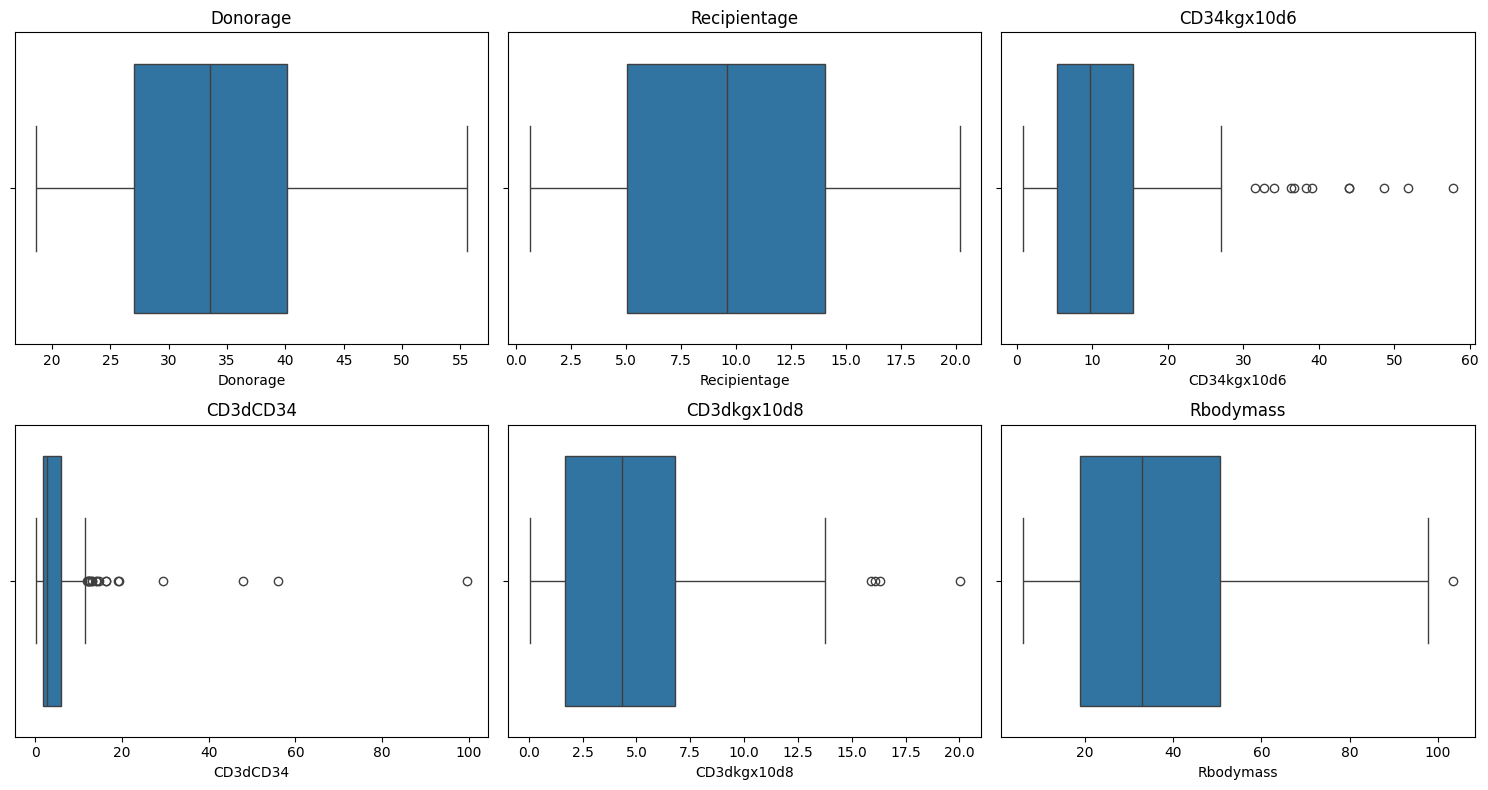

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64','int64']).columns

plt.figure(figsize=(15,8))
for i,col in enumerate(numeric_cols[:6]):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [14]:
df["survival_status"].value_counts()

survival_status
0.0    102
1.0     85
Name: count, dtype: int64

<Axes: xlabel='survival_status', ylabel='count'>

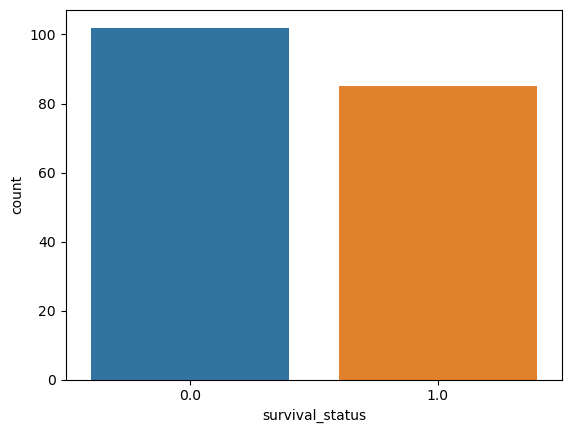

In [15]:
import seaborn as sns
sns.countplot(x="survival_status", data=df)

<Axes: >

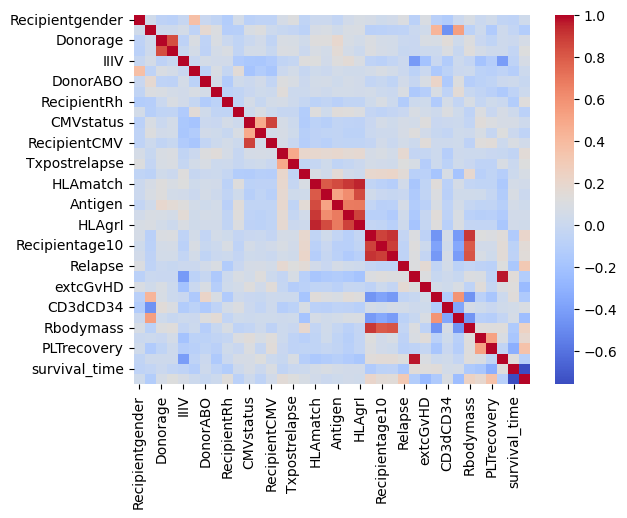

In [18]:
import numpy as np

# Remplacer les '?' par NaN
df = df.replace('?', np.nan)
# Convertir tout ce qui est possible en numérique
df = df.apply(pd.to_numeric, errors='ignore')
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

In [14]:
pip install xgboost lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import os
print(os.listdir())

['eda.ipynb']


In [8]:
import sys
!{sys.executable} -m pip install shap xgboost scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import shap
print(shap.__version__)

0.51.0


In [10]:
import sys
!{sys.executable} -m pip install shap xgboost scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (187, 37)

Columns:
Index(['Recipientgender', 'Stemcellsource', 'Donorage', 'Donorage35', 'IIIV',
       'Gendermatch', 'DonorABO', 'RecipientABO', 'RecipientRh', 'ABOmatch',
       'CMVstatus', 'DonorCMV', 'RecipientCMV', 'Disease', 'Riskgroup',
       'Txpostrelapse', 'Diseasegroup', 'HLAmatch', 'HLAmismatch', 'Antigen',
       'Alel', 'HLAgrI', 'Recipientage', 'Recipientage10', 'Recipientageint',
       'Relapse', 'aGvHDIIIIV', 'extcGvHD', 'CD34kgx10d6', 'CD3dCD34',
       'CD3dkgx10d8', 'Rbodymass', 'ANCrecovery', 'PLTrecovery',
       'time_to_aGvHD_III_IV', 'survival_time', 'survival_status'],
      dtype='str')

First rows:
  Recipientgender Stemcellsource   Donorage Donorage35 IIIV Gendermatch  \
0               1              1  22.830137          0    1           0   
1               1              0  23.342466          0    1           0   
2               1              0  26.394521          0    1           0   
3               0              0  39.684932          1

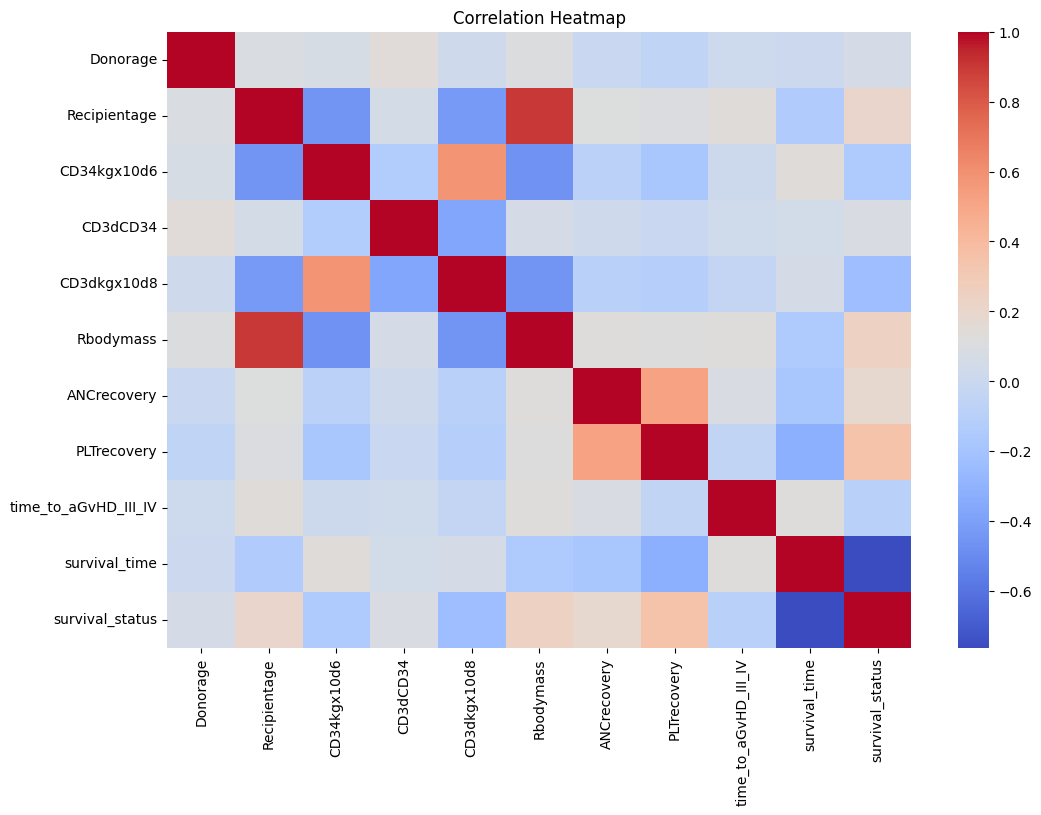

In [15]:
# ===== Imports =====
from pathlib import Path
from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== File path =====
file_path = Path("../data/bone-marrow.arff")

# ===== Load ARFF file =====
data, meta = arff.loadarff(file_path)

# ===== Convert to DataFrame =====
df = pd.DataFrame(data)

# ===== Convert bytes columns to string =====
for col in df.select_dtypes([object]):
    df[col] = df[col].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)

# ===== Basic info =====
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

# ===== Select numeric columns =====
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# ===== Correlation heatmap =====
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [12]:
import sys
!{sys.executable} -m pip install shap xgboost scikit-learn matplotlib pandas numpy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# pip install pandas numpy scikit-learn xgboost shap matplotlib

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Charger les données
# Remplace 'data.csv' par ton fichier
df = pd.read_csv("data.csv")

# Remplace 'target' par le nom de ta colonne cible
target_col = "target"

X = df.drop(columns=[target_col])
y = df[target_col]

# 2. Séparer train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entraîner le modèle
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# 4. Prédictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Évaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

# 6. Initialiser SHAP
explainer = shap.TreeExplainer(model)

# 7. Calcul des valeurs SHAP
shap_values = explainer.shap_values(X_test)

# 8. Summary Plot global
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()

# 9. Bar Plot des variables les plus importantes
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar.png", bbox_inches="tight")
plt.show()

# 10. Explication d'une seule observation
sample_index = 0

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_test.iloc[sample_index]
)

# Sauvegarde HTML
shap.save_html("shap_force_plot.html", force_plot)

# 11. Waterfall plot pour une observation
shap_exp = explainer(X_test)

plt.figure()
shap.plots.waterfall(shap_exp[sample_index], show=False)
plt.tight_layout()
plt.savefig("shap_waterfall.png", bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'